# Análise de Carga e Geração — Copa do Mundo

## Brasil | 2014 × 2026

Este estudo analisa o comportamento da **carga elétrica** e da **composição da geração** nos horários dos jogos do Brasil nas Copas do Mundo de 2014 e 2026, utilizando a base histórica do ONS.

A análise é feita para o **Sistema Interligado Nacional (SIN)** e compara os resultados com uma referência de carga construída a partir dos mesmos horários em uma janela de ±7 dias.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base histórica do ONS
df = pd.read_parquet("balanco_energia_ons.parquet")
df["din_instante"] = pd.to_datetime(df["din_instante"])


In [24]:
# ============================================================
# JOGOS DO BRASIL — 2014 E 2026
# ============================================================

jogos_brasil_2014 = pd.DataFrame({
    "data": [
        "2014-06-12",
        "2014-06-17",
        "2014-06-23",
        "2014-06-28",
        "2014-07-04",
        "2014-07-08",
        "2014-07-12"
    ],
    "horario": [
        "17:00",
        "16:00",
        "17:00",
        "13:00",
        "17:00",
        "17:00",
        "17:00"
    ],
    "adversario": [
        "Croácia",
        "México",
        "Camarões",
        "Chile",
        "Colômbia",
        "Alemanha",
        "Países Baixos"
    ]
})

jogos_brasil_2026 = pd.DataFrame({
    "data": [
        "2026-06-13",
        "2026-06-19",
        "2026-06-24",
        "2026-06-29",
        "2026-07-05"
    ],
    "horario": [
        "22:00",
        "22:00",
        "19:00",
        "16:00",
        "16:00"
    ],
    "adversario": [
        "Marrocos",
        "Haiti",
        "Escócia",
        "Japão",
        "Noruega"
    ]
})

for jogos in [jogos_brasil_2014, jogos_brasil_2026]:
    jogos["din_instante"] = pd.to_datetime(
        jogos["data"] + " " + jogos["horario"]
    )


In [15]:
# ============================================================
# RECORTE DO SIN NOS HORÁRIOS DOS JOGOS
# ============================================================

def extrair_jogos_sin(jogos):
    dados = df.merge(
        jogos[["din_instante", "adversario"]],
        on="din_instante",
        how="inner"
    )

    return dados[
        dados["nom_subsistema"] == "SISTEMA INTERLIGADO NACIONAL"
    ][
        [
            "din_instante",
            "adversario",
            "val_carga",
            "val_gerhidraulica",
            "val_gertermica",
            "val_gereolica",
            "val_gersolar",
            "val_intercambio"
        ]
    ].copy()

jogos_sin_2014 = extrair_jogos_sin(jogos_brasil_2014)
jogos_sin_2026 = extrair_jogos_sin(jogos_brasil_2026)


In [16]:
# ============================================================
# CARGA NOS JOGOS × CARGA DE REFERÊNCIA
# ============================================================

def criar_referencia_jogos(jogos, df_base, janela=7):
    resultados = []

    sin = df_base[
        df_base["nom_subsistema"] == "SISTEMA INTERLIGADO NACIONAL"
    ].copy()

    for _, jogo in jogos.iterrows():

        instante_jogo = jogo["din_instante"]

        inicio = instante_jogo - pd.Timedelta(days=janela)
        fim = instante_jogo + pd.Timedelta(days=janela)

        referencia = sin[
            (sin["din_instante"] >= inicio)
            & (sin["din_instante"] <= fim)
            & (sin["din_instante"].dt.hour == instante_jogo.hour)
            & (sin["din_instante"].dt.minute == instante_jogo.minute)
            & (sin["din_instante"] != instante_jogo)
        ]

        carga_jogo = sin.loc[
            sin["din_instante"] == instante_jogo,
            "val_carga"
        ].mean()

        carga_referencia = referencia["val_carga"].mean()

        variacao = (
            (carga_jogo - carga_referencia)
            / carga_referencia
            * 100
        )

        resultados.append({
            "data": instante_jogo,
            "adversario": jogo["adversario"],
            "carga_jogo": carga_jogo,
            "carga_referencia": carga_referencia,
            "variacao_%": variacao
        })

    return pd.DataFrame(resultados)

carga_jogos_2014 = criar_referencia_jogos(
    jogos_brasil_2014,
    df
)

carga_jogos_2026 = criar_referencia_jogos(
    jogos_brasil_2026,
    df
)


In [17]:
# ============================================================
# COMPOSIÇÃO MÉDIA DA GERAÇÃO
# ============================================================

fontes = {
    "Hidráulica": "val_gerhidraulica",
    "Térmica": "val_gertermica",
    "Eólica": "val_gereolica",
    "Solar": "val_gersolar"
}

def calcular_participacao(dados):
    valores = {
        fonte: dados[coluna].mean()
        for fonte, coluna in fontes.items()
    }

    total = sum(
        valor
        for valor in valores.values()
        if pd.notna(valor)
    )

    return {
        fonte: (
            valor / total * 100
            if pd.notna(valor)
            else np.nan
        )
        for fonte, valor in valores.items()
    }

participacao_pct = pd.DataFrame([
    {
        "Ano": 2014,
        **calcular_participacao(jogos_sin_2014)
    },
    {
        "Ano": 2026,
        **calcular_participacao(jogos_sin_2026)
    }
])

participacao_pct


,Ano,Hidráulica,Térmica,Eólica,Solar
0,2014,69.182480,28.731648,2.085871,NaN
1,2026,64.654911,13.021303,16.665301,5.658485


In [18]:
# ============================================================
# RESUMO EXECUTIVO
# ============================================================

def fonte_predominante(dados):
    medias = {
        fonte: dados[coluna].mean()
        for fonte, coluna in fontes.items()
    }

    medias = {
        fonte: valor
        for fonte, valor in medias.items()
        if pd.notna(valor)
    }

    return max(medias, key=medias.get)

resumo_executivo = pd.DataFrame({
    "Indicador": [
        "Carga média nos jogos (MW)",
        "Geração hidráulica média (MW)",
        "Geração térmica média (MW)",
        "Geração eólica média (MW)",
        "Geração solar média (MW)",
        "Variação média da carga vs referência (%)",
        "Fonte predominante"
    ],
    "2014": [
        jogos_sin_2014["val_carga"].mean(),
        jogos_sin_2014["val_gerhidraulica"].mean(),
        jogos_sin_2014["val_gertermica"].mean(),
        jogos_sin_2014["val_gereolica"].mean(),
        jogos_sin_2014["val_gersolar"].mean(),
        carga_jogos_2014["variacao_%"].mean(),
        fonte_predominante(jogos_sin_2014)
    ],
    "2026": [
        jogos_sin_2026["val_carga"].mean(),
        jogos_sin_2026["val_gerhidraulica"].mean(),
        jogos_sin_2026["val_gertermica"].mean(),
        jogos_sin_2026["val_gereolica"].mean(),
        jogos_sin_2026["val_gersolar"].mean(),
        carga_jogos_2026["variacao_%"].mean(),
        fonte_predominante(jogos_sin_2026)
    ]
})

resumo_executivo


,Indicador,2014,2026
0,Carga média nos jogos (MW),52731.688571,75013.684
1,Geração hidráulica média (MW),36481.088722,49325.6758
2,Geração térmica média (MW),15150.682812,9934.0414
3,Geração eólica média (MW),1099.915205,12714.0728
4,Geração solar média (MW),NaN,4316.8974
5,Variação média da carga vs referência (%),-16.167298,-8.870678
6,Fonte predominante,Hidráulica,Hidráulica


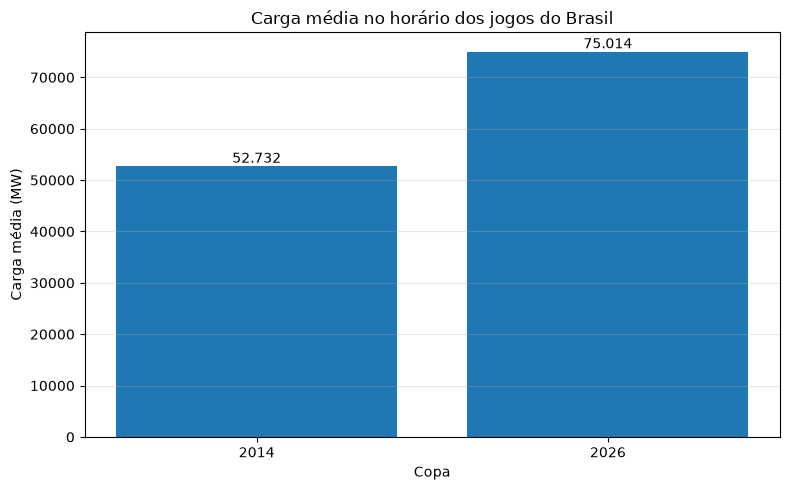

In [19]:
# ============================================================
# GRÁFICO 1 — CARGA MÉDIA NOS JOGOS
# ============================================================

carga_media = pd.DataFrame({
    "Copa": ["2014", "2026"],
    "Carga média (MW)": [
        jogos_sin_2014["val_carga"].mean(),
        jogos_sin_2026["val_carga"].mean()
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    carga_media["Copa"],
    carga_media["Carga média (MW)"]
)

ax.set_title("Carga média no horário dos jogos do Brasil")
ax.set_xlabel("Copa")
ax.set_ylabel("Carga média (MW)")
ax.grid(axis="y", alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:,.0f}".replace(",", "."),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


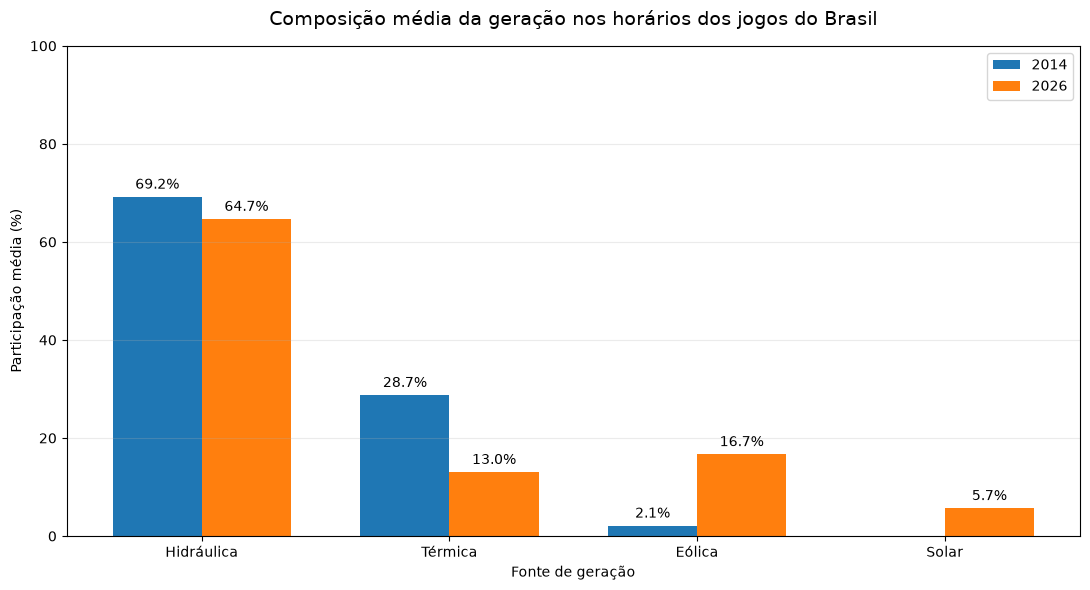

In [20]:
# ============================================================
# GRÁFICO 2 — COMPOSIÇÃO DA GERAÇÃO
# ============================================================

fontes_grafico = [
    "Hidráulica",
    "Térmica",
    "Eólica",
    "Solar"
]

dados_grafico = (
    participacao_pct
    .set_index("Ano")[fontes_grafico]
)

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(fontes_grafico))
largura = 0.36

barras_2014 = ax.bar(
    x - largura / 2,
    dados_grafico.loc[2014],
    largura,
    label="2014"
)

barras_2026 = ax.bar(
    x + largura / 2,
    dados_grafico.loc[2026],
    largura,
    label="2026"
)

ax.set_title(
    "Composição média da geração nos horários dos jogos do Brasil",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Fonte de geração")
ax.set_ylabel("Participação média (%)")
ax.set_xticks(x)
ax.set_xticklabels(fontes_grafico)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for barras in [barras_2014, barras_2026]:
    for barra in barras:
        altura = barra.get_height()

        if not np.isnan(altura):
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                altura + 1,
                f"{altura:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10
            )

plt.tight_layout()
plt.show()


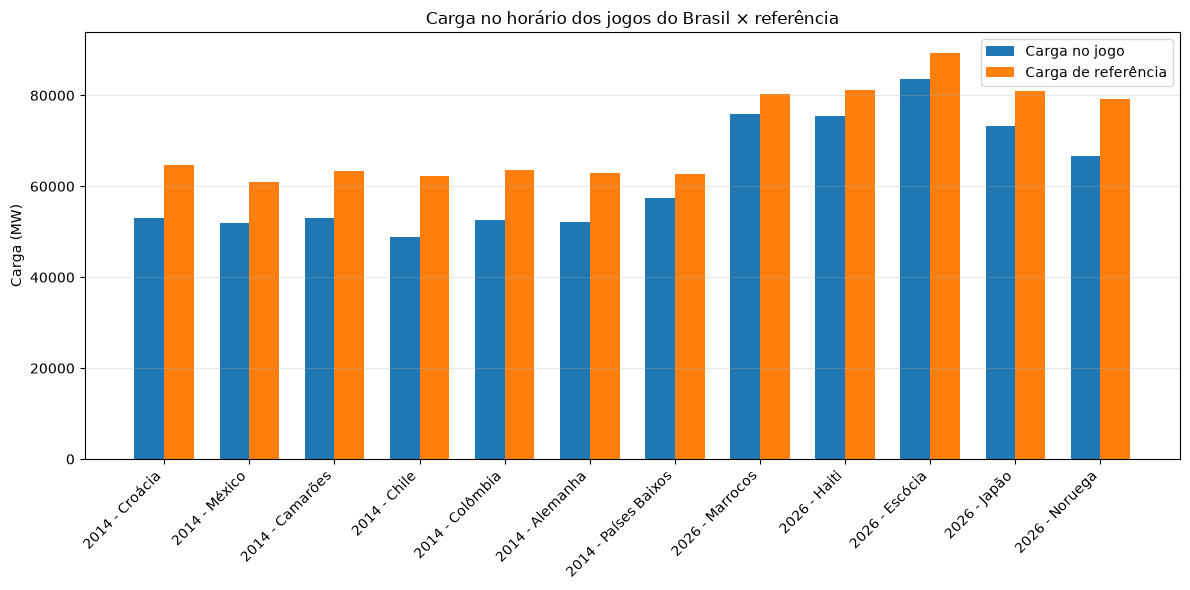

In [21]:
# ============================================================
# GRÁFICO 3 — CARGA NOS JOGOS × REFERÊNCIA
# ============================================================

grafico_carga = pd.concat(
    [
        carga_jogos_2014.assign(Copa="2014"),
        carga_jogos_2026.assign(Copa="2026")
    ],
    ignore_index=True
)

grafico_carga["Jogo"] = (
    grafico_carga["Copa"]
    + " - "
    + grafico_carga["adversario"]
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(grafico_carga))
largura = 0.35

ax.bar(
    x - largura / 2,
    grafico_carga["carga_jogo"],
    largura,
    label="Carga no jogo"
)

ax.bar(
    x + largura / 2,
    grafico_carga["carga_referencia"],
    largura,
    label="Carga de referência"
)

ax.set_title("Carga no horário dos jogos do Brasil × referência")
ax.set_ylabel("Carga (MW)")
ax.set_xticks(x)
ax.set_xticklabels(
    grafico_carga["Jogo"],
    rotation=45,
    ha="right"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


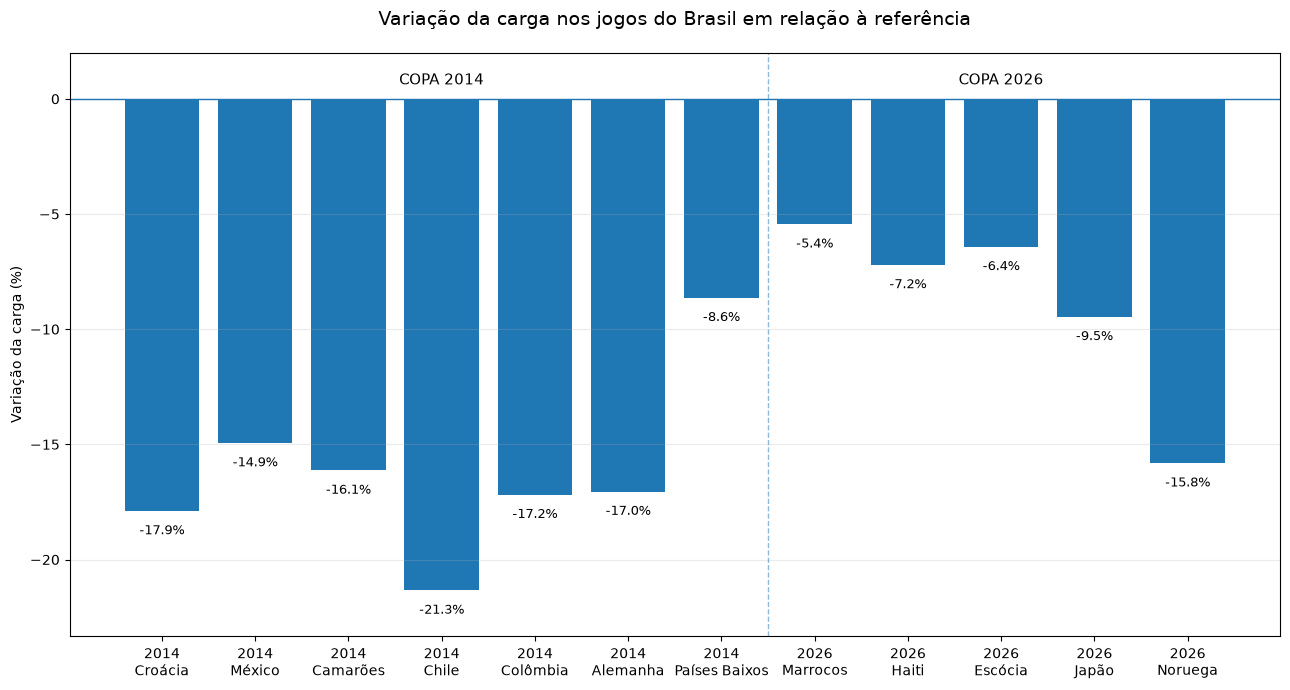

In [22]:
# ============================================================
# GRÁFICO 4 — VARIAÇÃO DA CARGA POR JOGO
# ============================================================

grafico_variacao = grafico_carga.copy()

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(grafico_variacao))
barras = ax.bar(
    x,
    grafico_variacao["variacao_%"]
)

ax.axhline(0, linewidth=1)
ax.axvline(
    6.5,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

ax.set_title(
    "Variação da carga nos jogos do Brasil em relação à referência",
    fontsize=14,
    pad=20
)

ax.set_ylabel("Variação da carga (%)")

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{ano}\n{adversario}"
        for ano, adversario in zip(
            grafico_variacao["Copa"],
            grafico_variacao["adversario"]
        )
    ]
)

ax.set_ylim(
    grafico_variacao["variacao_%"].min() - 2,
    2
)

ax.grid(axis="y", alpha=0.25)

for barra in barras:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura - 0.6,
        f"{altura:.1f}%",
        ha="center",
        va="top",
        fontsize=9
    )

ax.text(
    3,
    0.8,
    "COPA 2014",
    ha="center",
    va="center",
    fontsize=11
)

ax.text(
    9,
    0.8,
    "COPA 2026",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout()
plt.show()


# Conclusões executivas

## Objetivo

Analisar o comportamento da carga e da composição da geração do Sistema Interligado Nacional (SIN) nos horários dos jogos do Brasil nas Copas do Mundo de 2014 e 2026, comparando os resultados com uma referência de carga para os mesmos horários.

## Principais achados

### 1. Crescimento da carga

A carga média observada nos horários dos jogos aumentou de **52.731,7 MW em 2014 para 75.013,7 MW em 2026**, representando um crescimento de aproximadamente **42,3%**.

### 2. Mudança na composição da geração

A hidráulica permaneceu como a fonte predominante nos horários analisados, porém sua participação média caiu de **69,2% para 64,7%**.

A principal mudança ocorreu na composição das demais fontes:

- **Térmica:** 28,7% → 13,0%
- **Eólica:** 2,1% → 16,7%
- **Solar:** sem dado disponível em 2014 → 5,7%

Os resultados indicam uma composição de geração mais diversificada em 2026, com maior participação de eólica e solar e menor participação térmica.

### 3. Comportamento da carga durante os jogos

Todos os jogos analisados apresentaram carga inferior à referência adotada para o mesmo horário.

A variação média foi:

- **2014:** -16,17%
- **2026:** -8,87%

Assim, a diferença média em relação à referência foi **7,30 pontos percentuais menor em 2026**.

## Interpretação

Os dados sugerem que os horários dos jogos do Brasil coincidiram com níveis de carga inferiores aos observados na referência utilizada, tanto em 2014 quanto em 2026.

Ao mesmo tempo, a composição da geração observada nesses horários mudou significativamente entre os dois períodos, especialmente pela redução da participação térmica e pelo crescimento das fontes eólica e solar.

## Limitações metodológicas

Os resultados representam uma análise observacional e não permitem afirmar que os jogos foram a causa direta das variações de carga.

A referência utilizada considera os mesmos horários em uma janela de dias próximos aos jogos, mas não controla integralmente fatores como:

- dia da semana;
- condições climáticas;
- temperatura;
- feriados;
- características específicas de cada dia;
- outros eventos que possam afetar o consumo de energia.

Além disso, a quantidade de jogos analisados é diferente entre os períodos: **7 jogos em 2014 e 5 jogos em 2026**.

Portanto, os resultados devem ser interpretados como **evidências de comportamento observado**, e não como uma estimativa causal do impacto dos jogos sobre a demanda.
